# Waddington folding as a full-Stokes positive control

This notebook demonstrates the two-stage mechanism described by [Waddington, Bolzan, and Alley (2001)](https://doi.org/10.3189/172756501781831756) and [Jacobson and Waddington (2004)](https://doi.org/10.3189/172756504781830204). A transient process first seeds a finite wrinkle. A steady, vertically sheared ice flow then passively rotates one limb through vertical and makes a recumbent fold.

The purpose is a positive control: unlike the three hypothesis notebooks, this calculation is deliberately configured to fold. The velocity is nevertheless an actual two-dimensional full-Stokes solution, not a prescribed interior field. A flat-layer control uses the same solution.

## Mechanical model and scaling

The domain is a 6 km long, 500 m thick parallel-sided slab inclined by 0.03. Velocity $\mathbf{u}=(u,w)$ and pressure $p$ satisfy

$$-\nabla\cdot[2\mu\,\mathrm{sym}(\nabla\mathbf{u})-p\mathbf{I}]=\rho\mathbf{g},\qquad \nabla\cdot\mathbf{u}=0.$$

I use continuous quadratic velocity and continuous linear pressure (P2--P1), constant viscosity $\mu=2.5\times10^8$ Pa yr, density 917 kg m$^{-3}$, and gravity 9.81 m s$^{-2}$. The bed is no slip, the surface is stress free, and the two sides have the analytical gravity-driven slab profile. No interior velocity is prescribed.

The thickness and speed are plausible orders of magnitude for slow Antarctic ice, but the viscosity is an effective value and the 3% slope is closer to a locally steep Allan Hills setting than a regional mean. The 25 kyr experiment is a mechanism demonstration, not a site reconstruction.

In [1]:
import logging
import warnings
warnings.filterwarnings("ignore", message="Unable to import recommended hash.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from IPython.display import Markdown, display
import firedrake as fd
logging.getLogger("tsfc").setLevel(logging.ERROR)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})

L, H = 6_000.0, 500.0             # m
RHO, G, ALPHA = 917.0, 9.81, 0.03
MU = 2.5e8                         # Pa yr
DURATION = 25_000.0                # yr
DT = 250.0                         # yr
SEED_AMPLITUDE = 25.0              # m
SEED_WAVELENGTH = 500.0            # m
AGE_SCALE = 15.0                   # m; schematic basal age compression
PLEISTOCENE_LIMIT = 2.58            # Ma
OLD_LIMIT = 4.8                    # Ma
DRIVING = RHO * G * np.sin(ALPHA)
ANALYTIC_SURFACE_SPEED = DRIVING * H**2 / (2 * MU)
ANALYTIC_BED_SHEAR = DRIVING * H / MU
INITIAL_MAX_SLOPE = 2 * np.pi * SEED_AMPLITUDE / SEED_WAVELENGTH

display(Markdown(
    f"Analytical slab scaling gives surface speed **{ANALYTIC_SURFACE_SPEED:.3f} m yr$^{{-1}}$**, "
    f"basal $u_z=$ **{ANALYTIC_BED_SHEAR:.3e} yr$^{{-1}}$**, and basal shear strain "
    f"$u_zT=$ **{ANALYTIC_BED_SHEAR * DURATION:.2f}**. The seed's maximum initial dip is "
    f"**{np.degrees(np.arctan(INITIAL_MAX_SLOPE)):.1f}°**."
))

Analytical slab scaling gives surface speed **0.135 m yr$^{-1}$**, basal $u_z=$ **5.397e-04 yr$^{-1}$**, and basal shear strain $u_zT=$ **13.49**. The seed's maximum initial dip is **17.4°**.

In [2]:
def solve_stokes(nx, nz):
    mesh = fd.RectangleMesh(nx, nz, L, H, quadrilateral=False)
    V = fd.VectorFunctionSpace(mesh, "CG", 2)
    Q = fd.FunctionSpace(mesh, "CG", 1)
    Z = V * Q
    z = fd.SpatialCoordinate(mesh)[1]

    u, p = fd.TrialFunctions(Z)
    v, q = fd.TestFunctions(Z)
    body_force = fd.Constant((RHO * G * np.sin(ALPHA), -RHO * G * np.cos(ALPHA)))
    a = (
        2 * MU * fd.inner(fd.sym(fd.grad(u)), fd.sym(fd.grad(v)))
        - p * fd.div(v) - q * fd.div(u)
    ) * fd.dx
    ell = fd.dot(body_force, v) * fd.dx

    side_velocity = fd.as_vector((DRIVING / MU * (H * z - 0.5 * z**2), 0.0))
    bcs = [
        fd.DirichletBC(Z.sub(0), side_velocity, 1),
        fd.DirichletBC(Z.sub(0), side_velocity, 2),
        fd.DirichletBC(Z.sub(0), fd.Constant((0.0, 0.0)), 3),
    ]
    solution = fd.Function(Z, name=f"stokes_{nx}_{nz}")
    fd.solve(
        a == ell, solution, bcs=bcs,
        solver_parameters={
            "ksp_type": "preonly", "pc_type": "lu",
            "pc_factor_mat_solver_type": "mumps",
        },
    )
    velocity, pressure = solution.subfunctions
    V1 = fd.VectorFunctionSpace(mesh, "CG", 1)
    Q1 = fd.FunctionSpace(mesh, "CG", 1)
    velocity_p1 = fd.Function(V1).interpolate(velocity)
    shear = fd.project(velocity[0].dx(1), Q1)
    divergence = fd.project(fd.div(velocity), Q1)
    normal = fd.FacetNormal(mesh)
    fluxes = np.array([float(fd.assemble(fd.dot(velocity, normal) * fd.ds(k))) for k in (1, 2, 3, 4)])
    gross_flux = np.sum(np.abs(fluxes))
    div_l2 = np.sqrt(float(fd.assemble(divergence**2 * fd.dx)))
    grad_l2 = np.sqrt(float(fd.assemble(fd.inner(fd.grad(velocity), fd.grad(velocity)) * fd.dx)))
    return {
        "mesh": mesh, "velocity": velocity, "velocity_p1": velocity_p1,
        "pressure": pressure, "shear": shear, "fluxes": fluxes,
        "mass_residual": abs(np.sum(fluxes)) / gross_flux,
        "divergence_ratio": div_l2 / grad_l2,
        "max_speed": float(np.max(np.linalg.norm(velocity_p1.dat.data_ro, axis=1))),
        "max_shear": float(np.max(np.abs(shear.dat.data_ro))),
        "nx": nx, "nz": nz,
    }

coarse = solve_stokes(48, 8)
fine = solve_stokes(96, 16)
table = [
    "| Mesh | Maximum speed (m yr$^{-1}$) | Maximum $|u_z|$ (yr$^{-1}$) | Relative divergence | Flux residual |",
    "|---|---:|---:|---:|---:|",
]
for result in (coarse, fine):
    table.append(
        f"| {result['nx']} × {result['nz']} | {result['max_speed']:.4f} | "
        f"{result['max_shear']:.3e} | {result['divergence_ratio']:.3e} | "
        f"{result['mass_residual']:.3e} |"
    )
display(Markdown("\n".join(table)))

| Mesh | Maximum speed (m yr$^{-1}$) | Maximum $|u_z|$ (yr$^{-1}$) | Relative divergence | Flux residual |
|---|---:|---:|---:|---:|
| 48 × 8 | 0.1349 | 5.397e-04 | 1.797e-15 | 4.294e-15 |
| 96 × 16 | 0.1349 | 5.397e-04 | 1.992e-15 | 1.197e-14 |

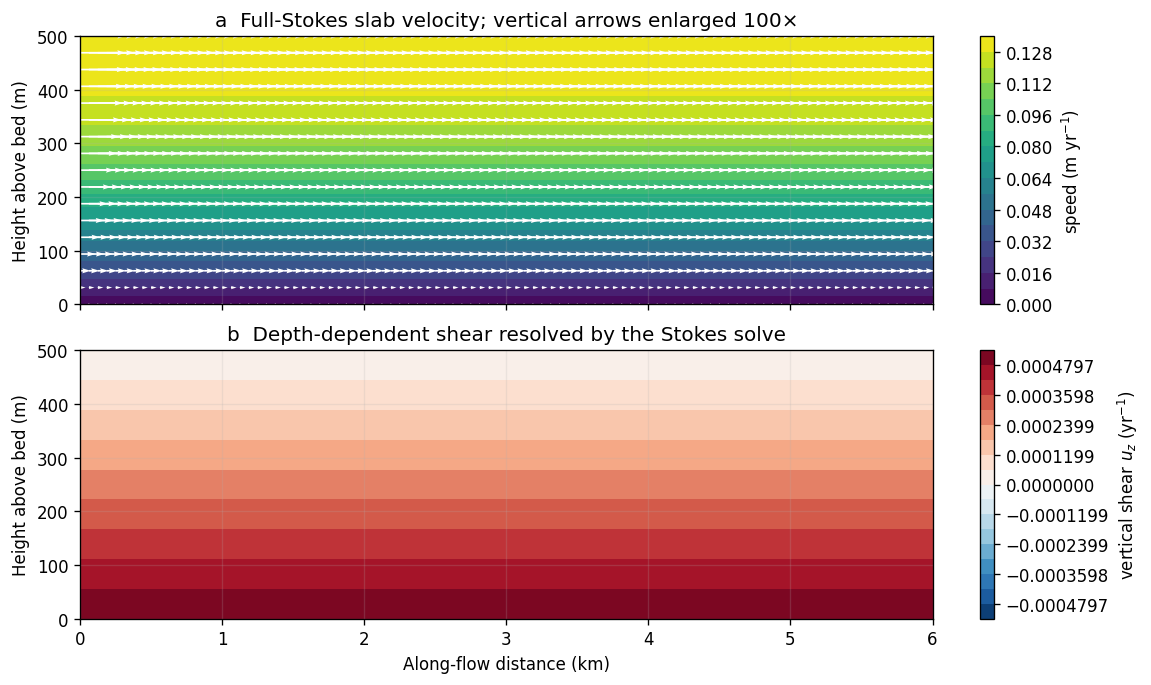

In [3]:
mesh = fine["mesh"]
xy = mesh.coordinates.dat.data_ro
triangles = mesh.coordinates.function_space().cell_node_map().values
triangulation = mtri.Triangulation(xy[:, 0] / 1000, xy[:, 1], triangles)
uv = fine["velocity_p1"].dat.data_ro
speed = np.linalg.norm(uv, axis=1)
shear = fine["shear"].dat.data_ro

fig, axes = plt.subplots(2, 1, figsize=(9.5, 5.6), sharex=True, constrained_layout=True)
c0 = axes[0].tricontourf(triangulation, speed, levels=18, cmap="viridis")
axes[0].quiver(xy[:, 0] / 1000, xy[:, 1], uv[:, 0], 100 * uv[:, 1],
               color="white", scale=2.5, width=0.002)
fig.colorbar(c0, ax=axes[0], label=r"speed (m yr$^{-1}$)")
axes[0].set(ylabel="Height above bed (m)", title="a  Full-Stokes slab velocity; vertical arrows enlarged 100×")
limit = np.max(np.abs(shear))
c1 = axes[1].tricontourf(triangulation, shear, levels=np.linspace(-limit, limit, 19), cmap="RdBu_r")
fig.colorbar(c1, ax=axes[1], label=r"vertical shear $u_z$ (yr$^{-1}$)")
axes[1].set(xlabel="Along-flow distance (km)", ylabel="Height above bed (m)",
            title="b  Depth-dependent shear resolved by the Stokes solve")
plt.show()

## Seed wrinkle and finite-strain test

Material layers begin as $z(X)=z_0+A\sin(2\pi X/\lambda)$ with $A=25$ m and $\lambda=500$ m. Their maximum initial dip is 17.4°. The flat control has $A=0$. Ages increase monotonically downward before deformation. To make an age reversal visually explicit, the nominal ages are compressed into the bottom tens of meters with a 15 m exponential scale. That age--depth relation is schematic and deliberately extreme; only its initially monotonic order matters here.

For ideal simple shear, $x=X+u(z)t$, so a segment overturns when

$$\frac{\partial x}{\partial X}=1+t\,u_z\frac{\partial z}{\partial X}<0.$$

This is the finite-strain form of the $-m^2u_z$ rotation term in the Waddington slope equation. The particle calculation below uses the solved velocity rather than the analytical profile.

In [4]:
def velocity_interpolator(result):
    mesh = result["mesh"]
    coordinates = mesh.coordinates.dat.data_ro.copy()
    values = result["velocity_p1"].dat.data_ro.copy()
    cells = mesh.coordinates.function_space().cell_node_map().values.copy()
    tri = mtri.Triangulation(coordinates[:, 0], coordinates[:, 1], cells)
    iu = mtri.LinearTriInterpolator(tri, values[:, 0])
    iw = mtri.LinearTriInterpolator(tri, values[:, 1])
    def sample(points):
        u = np.ma.filled(iu(points[:, 0], points[:, 1]), np.nan)
        w = np.ma.filled(iw(points[:, 0], points[:, 1]), np.nan)
        return np.column_stack((u, w))
    return sample

X0 = np.linspace(300.0, 2_200.0, 381)
BASE_HEIGHTS = np.linspace(30.0, 470.0, 61)
LAYER_AGES = 0.2 + 5.0 * np.exp(-(BASE_HEIGHTS - 30.0) / AGE_SCALE)

def advect_layers(result, amplitude):
    phase = 2 * np.pi * (X0 - X0.min()) / SEED_WAVELENGTH
    x = np.broadcast_to(X0, (len(BASE_HEIGHTS), len(X0))).copy()
    z = BASE_HEIGHTS[:, None] + amplitude * np.sin(phase)[None, :]
    initial_x, initial_z = x.copy(), z.copy()
    sample = velocity_interpolator(result)
    for _ in range(round(DURATION / DT)):
        points = np.column_stack((x.ravel(), z.ravel()))
        k1 = sample(points)
        midpoint = points + 0.5 * DT * k1
        k2 = sample(midpoint)
        if not np.all(np.isfinite(k2)):
            raise RuntimeError("A marker left the Stokes domain")
        final = points + DT * k2
        x = final[:, 0].reshape(x.shape)
        z = final[:, 1].reshape(z.shape)
    dx = np.diff(x, axis=1)
    dz = np.diff(z, axis=1)
    return {
        "initial_x": initial_x, "initial_z": initial_z, "x": x, "z": z,
        "overturned": int(np.count_nonzero(dx < 0.0)),
        "max_angle": float(np.degrees(np.max(np.abs(np.arctan2(dz, dx))))),
        "minimum_mapping": float(np.min(dx / np.diff(initial_x, axis=1))),
    }

def core_intersections(layers, x_core):
    intersections = []
    for row, age in enumerate(LAYER_AGES):
        x, z = layers["x"][row], layers["z"][row]
        for j in np.flatnonzero((x[:-1] - x_core) * (x[1:] - x_core) <= 0.0):
            if x[j + 1] == x[j]:
                continue
            fraction = (x_core - x[j]) / (x[j + 1] - x[j])
            if 0.0 <= fraction <= 1.0:
                height = z[j] + fraction * (z[j + 1] - z[j])
                intersections.append((height, age, row))
    intersections.sort(reverse=True)
    return intersections

def passing_minima(intersections):
    ages = np.array([item[1] for item in intersections])
    passing = []
    for j in np.flatnonzero(ages <= PLEISTOCENE_LIMIT):
        if j == 0 or j == len(ages) - 1:
            continue
        old_above = np.max(ages[:j])
        old_below = np.max(ages[j + 1:])
        if old_above >= OLD_LIMIT and old_below >= OLD_LIMIT:
            passing.append((j, old_above, ages[j], old_below))
    return passing

def scan_cores(layers):
    best = None
    for x_core in np.linspace(500.0, 5_600.0, 341):
        intersections = core_intersections(layers, x_core)
        passes = passing_minima(intersections)
        ages = np.array([item[1] for item in intersections])
        reversals = int(np.count_nonzero(np.diff(ages) < 0.0)) if len(ages) > 1 else 0
        contrast = max((min(above, below) - young for _, above, young, below in passes), default=-1.0)
        score = (len(passes), contrast, reversals, len(intersections))
        if best is None or score > best[0]:
            best = (score, x_core, intersections, passes)
    return {"score": best[0], "x": best[1], "intersections": best[2], "passes": best[3]}

In [5]:
coarse_fold = advect_layers(coarse, SEED_AMPLITUDE)
fine_fold = advect_layers(fine, SEED_AMPLITUDE)
fine_flat = advect_layers(fine, 0.0)
coarse_core = scan_cores(coarse_fold)
fine_core = scan_cores(fine_fold)
flat_core = scan_cores(fine_flat)

# The first fold time follows directly from the solved steady field.
sample = velocity_interpolator(fine)
initial_points = np.column_stack((fine_fold["initial_x"].ravel(), fine_fold["initial_z"].ravel()))
initial_u = sample(initial_points)[:, 0].reshape(fine_fold["initial_x"].shape)
dX = np.diff(fine_fold["initial_x"], axis=1)
dU = np.diff(initial_u, axis=1)
fold_times = -dX[dU < 0.0] / dU[dU < 0.0]
first_fold_time = float(np.min(fold_times))

selected = max(fine_core["passes"], key=lambda item: min(item[1], item[3]) - item[2])
_, old_above, young, old_below = selected
display(Markdown(
    f"The first segment passes through vertical after **{first_fold_time / 1000:.1f} kyr**. "
    f"At 25 kyr the fine mesh has **{fine_fold['overturned']} overturned segments** and "
    f"**{len(fine_core['passes'])} passing Pleistocene minima**. Its best core contains the "
    f"top-to-bottom triplet **{old_above:.2f} → {young:.2f} → {old_below:.2f} Ma**. "
    f"The flat control has **{fine_flat['overturned']} overturned segments** and "
    f"**{len(flat_core['passes'])} passing minima**. The coarse mesh gives "
    f"**{coarse_fold['overturned']} overturned segments** and "
    f"**{len(coarse_core['passes'])} passing minima**."
))

The first segment passes through vertical after **6.1 kyr**. At 25 kyr the fine mesh has **6596 overturned segments** and **6 passing Pleistocene minima**. Its best core contains the top-to-bottom triplet **5.20 → 0.91 → 5.20 Ma**. The flat control has **0 overturned segments** and **0 passing minima**. The coarse mesh gives **6556 overturned segments** and **6 passing minima**.

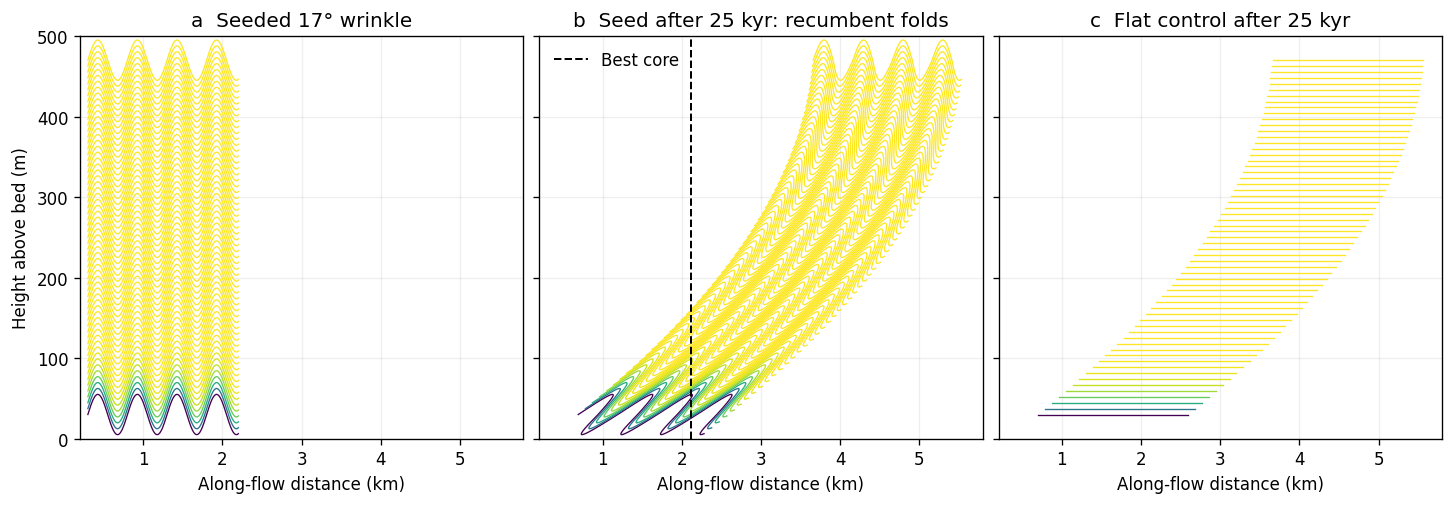

In [6]:
colors = plt.cm.viridis_r((LAYER_AGES - LAYER_AGES.min()) / np.ptp(LAYER_AGES))
fig, axes = plt.subplots(1, 3, figsize=(12, 4.1), sharey=True, constrained_layout=True)
for row, color in enumerate(colors):
    axes[0].plot(fine_fold["initial_x"][row] / 1000, fine_fold["initial_z"][row], color=color, lw=0.8)
    axes[1].plot(fine_fold["x"][row] / 1000, fine_fold["z"][row], color=color, lw=0.8)
    axes[2].plot(fine_flat["x"][row] / 1000, fine_flat["z"][row], color=color, lw=0.8)
axes[1].axvline(fine_core["x"] / 1000, color="black", ls="--", lw=1.2, label="Best core")
axes[1].legend(frameon=False)
axes[0].set_title("a  Seeded 17° wrinkle")
axes[1].set_title("b  Seed after 25 kyr: recumbent folds")
axes[2].set_title("c  Flat control after 25 kyr")
for axis in axes:
    axis.set(xlabel="Along-flow distance (km)", xlim=(0.2, 5.8), ylim=(0, H))
axes[0].set_ylabel("Height above bed (m)")
plt.show()

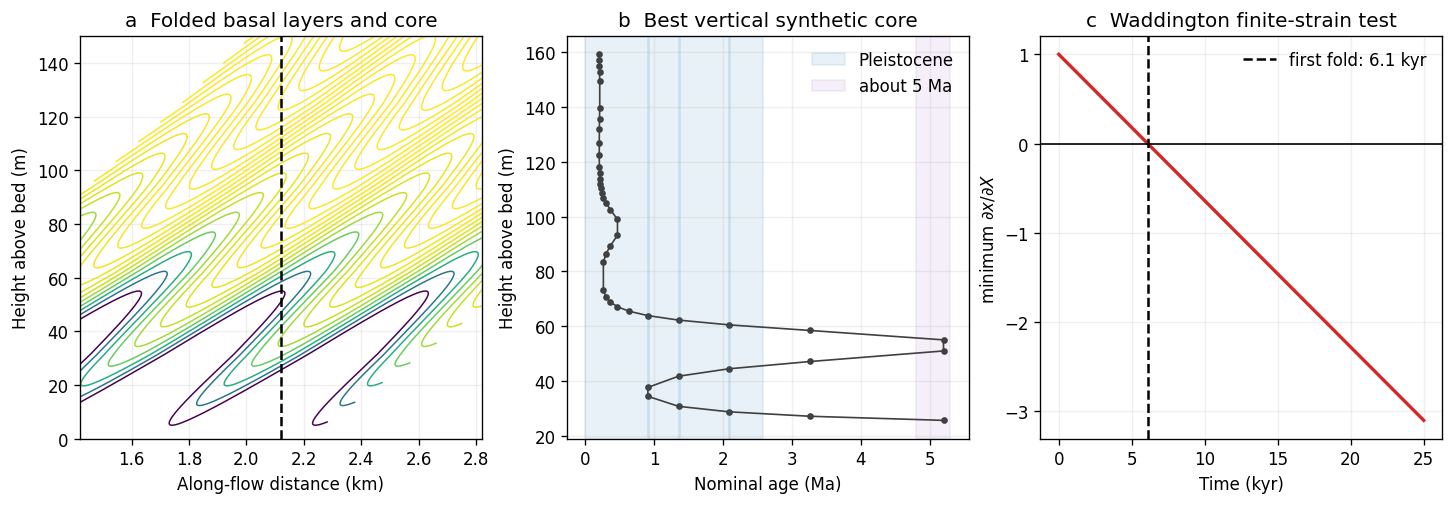

In [7]:
intersections = fine_core["intersections"]
heights = np.array([item[0] for item in intersections])
ages = np.array([item[1] for item in intersections])
times = np.linspace(0.0, DURATION, 201)
minimum_mapping = np.array([np.min((dX + time * dU) / dX) for time in times])

fig, axes = plt.subplots(1, 3, figsize=(12, 4.1), constrained_layout=True)
for row, color in enumerate(colors):
    axes[0].plot(fine_fold["x"][row] / 1000, fine_fold["z"][row], color=color, lw=0.9)
axes[0].axvline(fine_core["x"] / 1000, color="black", ls="--")
axes[0].set(xlabel="Along-flow distance (km)", ylabel="Height above bed (m)",
            title="a  Folded basal layers and core", xlim=(fine_core["x"] / 1000 - 0.7, fine_core["x"] / 1000 + 0.7), ylim=(0, 150))
axes[1].plot(ages, heights, "o-", ms=3, lw=1, color="0.25")
for _, above, young_age, below in fine_core["passes"]:
    axes[1].axvline(young_age, color="tab:blue", alpha=0.08)
axes[1].axvspan(0, PLEISTOCENE_LIMIT, color="tab:blue", alpha=0.10, label="Pleistocene")
axes[1].axvspan(OLD_LIMIT, 5.3, color="tab:purple", alpha=0.10, label="about 5 Ma")
axes[1].set(xlabel="Nominal age (Ma)", ylabel="Height above bed (m)",
            title="b  Best vertical synthetic core")
axes[1].legend(frameon=False)
axes[2].plot(times / 1000, minimum_mapping, color="tab:red", lw=2)
axes[2].axhline(0, color="black", lw=1)
axes[2].axvline(first_fold_time / 1000, color="black", ls="--", label=f"first fold: {first_fold_time/1000:.1f} kyr")
axes[2].set(xlabel="Time (kyr)", ylabel=r"minimum $\partial x/\partial X$",
            title="c  Waddington finite-strain test")
axes[2].legend(frameon=False)
plt.show()

## Interpretation

This is a successful demonstration of the Waddington mechanism. The solved Stokes field supplies depth-dependent simple shear. That shear cannot fold the flat control, but it rotates the negative-slope limb of a pre-existing 17° wrinkle through vertical in a few kyr. Continued deformation produces recumbent folds, repeated layer intersections, and a synthetic core containing approximately 5 Ma ice above Pleistocene ice and older ice below.

The result identifies what the three negative hypothesis tests lacked: not vertical shear, but a sufficiently steep and appropriately oriented seed disturbance. It does not identify how Allan Hills created such a wrinkle. The 25 m seed amplitude, 500 m wavelength, constant effective viscosity, parallel-sided geometry, and especially the 15 m nominal age-compression scale are illustrative. The age labels test layer order only; isotope diffusion and the timing of first old--young contact are not modeled. A useful next step is therefore to ask which transient Allan Hills forcing can create a seed near or above this finite-strain threshold.